In [3]:
# THIRANEX TASK 3 - EXPLORATORY DATA ANALYSIS (EDA)
# Netflix Movies and TV Shows

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Upload dataset
uploaded = files.upload()

# Get uploaded file name
file_name = list(uploaded.keys())[0]

# Load dataset
df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Saving archive.zip to archive.zip
Dataset loaded successfully!
Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
print("===== DATASET INFORMATION =====")

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

===== DATASET INFORMATION =====

Number of Rows: 8807
Number of Columns: 12

Column Names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [5]:
print("===== STATISTICAL SUMMARY =====")

display(df.describe(include="all").T)

===== STATISTICAL SUMMARY =====


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s8807,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Zubaan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Make a copy
data = df.copy()

# Fill missing values
for column in data.columns:
    if data[column].dtype == "object":
        data[column] = data[column].fillna("Unknown")
    else:
        data[column] = data[column].fillna(data[column].median())

# Remove duplicate rows
data = data.drop_duplicates()

print("After cleaning:")
print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

print("\nRemaining missing values:")
print(data.isnull().sum())


After cleaning:
Rows: 8807
Columns: 12

Remaining missing values:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


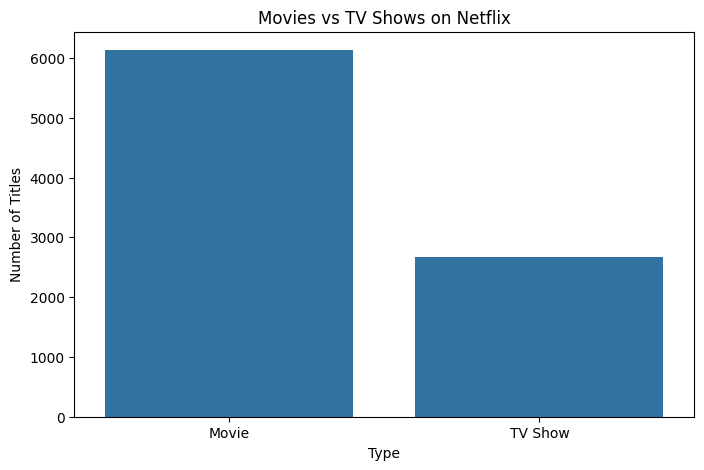

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(data=data, x="type")

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Number of Titles")
plt.show()


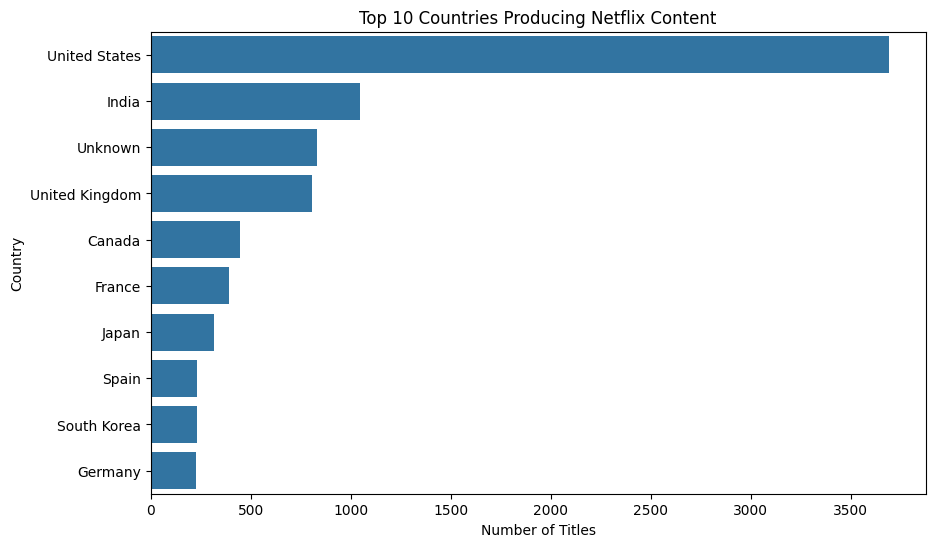

In [8]:
# Split countries and count them
countries = data["country"].str.split(", ").explode()

top_countries = countries.value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()


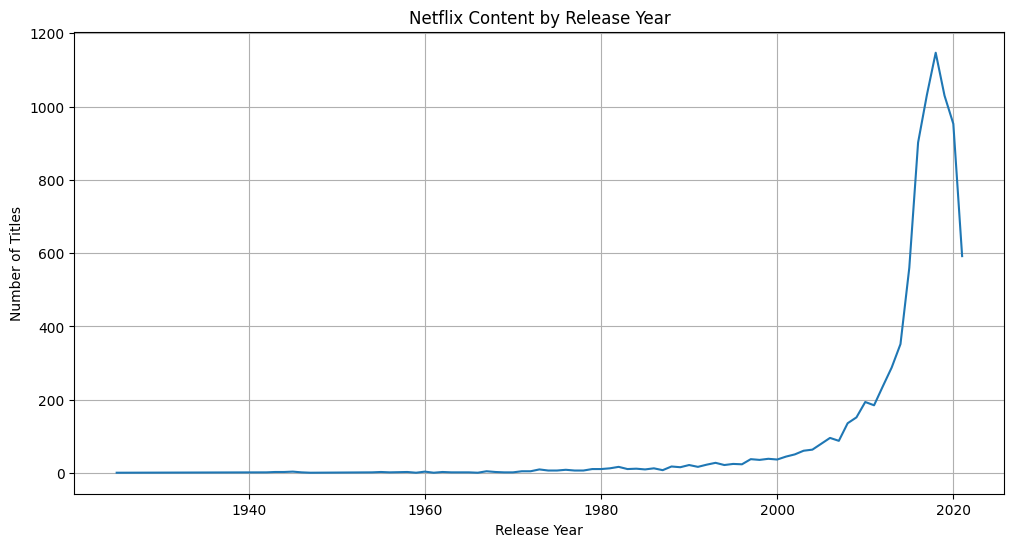

In [9]:
year_count = data["release_year"].value_counts().sort_index()

plt.figure(figsize=(12,6))

plt.plot(year_count.index, year_count.values)

plt.title("Netflix Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True)

plt.show()

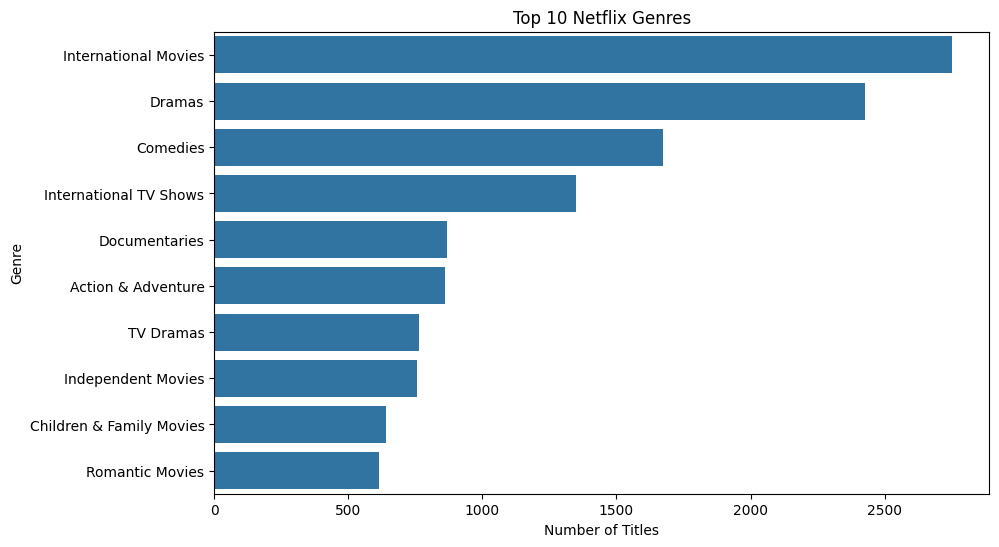

In [10]:
genres = data["listed_in"].str.split(", ").explode()

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_genres.values, y=top_genres.index)

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

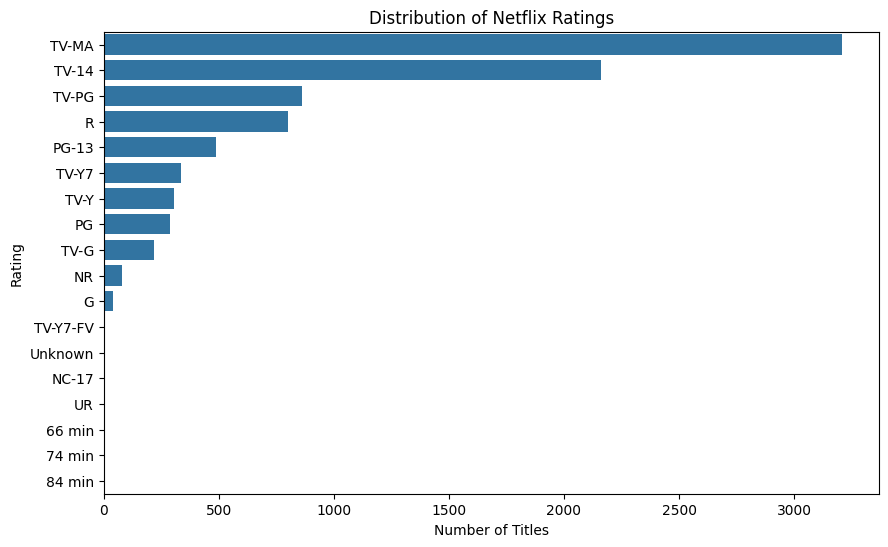

In [11]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=data,
    y="rating",
    order=data["rating"].value_counts().index
)

plt.title("Distribution of Netflix Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")
plt.show()

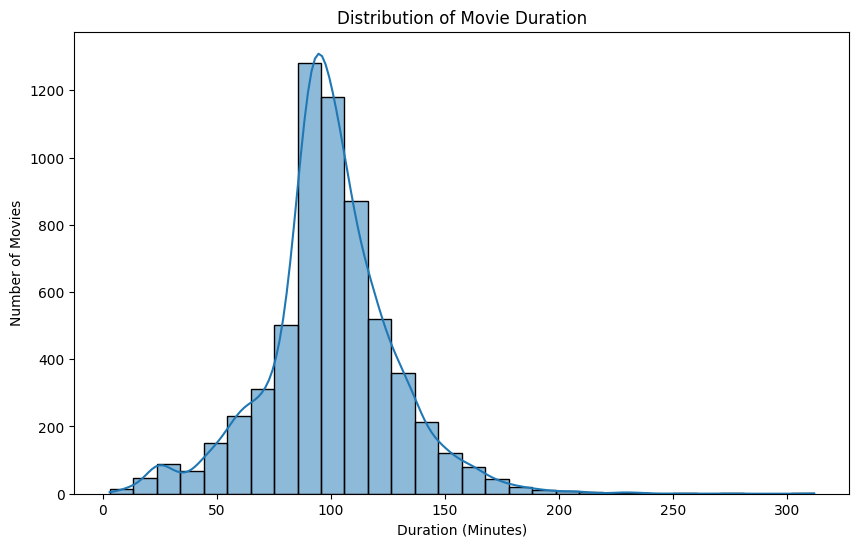

In [12]:
movies = data[data["type"] == "Movie"].copy()

movies["duration_minutes"] = (
    movies["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)

plt.figure(figsize=(10,6))

sns.histplot(
    movies["duration_minutes"].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of Movie Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.show()

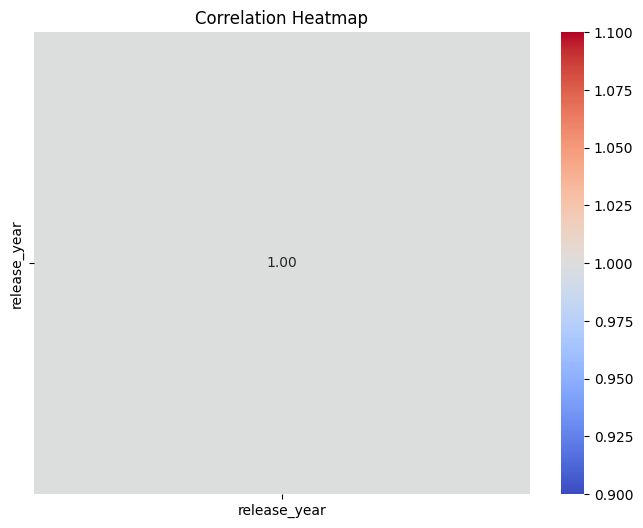

In [13]:
# Select numerical columns
numeric_data = data.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [14]:
print("========== KEY FINDINGS ==========")

most_common_type = data["type"].mode()[0]
most_common_rating = data["rating"].mode()[0]
latest_year = data["release_year"].max()

print("1. Most common content type:", most_common_type)
print("2. Most common rating:", most_common_rating)
print("3. Latest release year in dataset:", latest_year)
print("4. Number of movies:", (data["type"] == "Movie").sum())
print("5. Number of TV shows:", (data["type"] == "TV Show").sum())
print("6. Most common genre:", genres.value_counts().index[0])
print("7. Top content-producing country:", countries.value_counts().index[0])

print("\nEDA completed successfully!")

========== KEY FINDINGS ==========
1. Most common content type: Movie
2. Most common rating: TV-MA
3. Latest release year in dataset: 2021
4. Number of movies: 6131
5. Number of TV shows: 2676
6. Most common genre: International Movies
7. Top content-producing country: United States

EDA completed successfully!


In [15]:
data.to_csv("netflix_cleaned_eda.csv", index=False)

files.download("netflix_cleaned_eda.csv")

print("Cleaned dataset downloaded successfully!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Cleaned dataset downloaded successfully!
